# למה `gpt-realtime` מהיר מ־`eleven_v3_conversational`

כל מספר כאן נמדד משיחות אמיתיות של המערכת הזו, בעברית — לא מדף שיווקי.
המקור הוא ה־session traces של האפליקציה, ומדידות ישירות מול ה־APIים.

**הטענה בשורה אחת:** הפער אינו במודל ואינו בקול. הוא בארכיטקטורה,
והוא נשרף לפני ששלב הקול בכלל מתחיל.

> תוויות הגרפים באנגלית בכוונה — matplotlib לא מרנדר עברית מימין לשמאל,
> וטקסט הפוך בשקף גרוע מטקסט באנגלית.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

OPENAI, ELEVEN, NEUTRAL = '#2563eb', '#dc2626', '#6b7280'

## הנתונים

| מדד | איך נמדד |
|---|---|
| `OPENAI_MS` | מ־`speech_stopped` ועד המילה המדוברת הראשונה |
| `ELEVEN_MS` | מהתמלול ועד ההודעה המלאה — **לא כולל זיהוי**, כלומר מוטה לטובתו |
| `CHAT_MS` | אותו LLM בדיוק, דרך `/api/chat` שלנו, בלי שום פלטפורמת קול |

**קטעים שנקטעו הוצאו.** תשובה של מילה אחת היא לא תשובה, והיא מושכת ממוצע כלפי מטה.

In [2]:
# speech end -> first spoken word. gpt-realtime, one session, 6 turns.
OPENAI_MS = [1900, 4800, 4300, 4400, 1200, 1400]

# transcript -> complete answer. ElevenLabs cascade, four sessions, 13 turns.
ELEVEN_MS = [7988, 7457, 12002, 4278, 11939, 2730,
             15349, 7610, 9069, 7282, 5526, 9830, 6853]

# barge-in fragments, excluded: they are not answers
ELEVEN_TRUNCATED = [612, 519, 1078, 414, 769]

# the control: same gemini-3.1-flash-lite, same tools, no voice platform
CHAT_MS = [2882, 2109, 2989]

# the deterministic scoring engine, identical on both paths
TOOL_MS = [41, 82, 39, 40, 83, 39, 85, 38]

for name, xs in [('gpt-realtime', OPENAI_MS), ('elevenlabs', ELEVEN_MS),
                 ('our /api/chat', CHAT_MS), ('scoring engine', TOOL_MS)]:
    print(f'{name:16} n={len(xs):2}   median {int(np.median(xs)):>6} ms   mean {int(np.mean(xs)):>6} ms')

gpt-realtime     n= 6   median   3100 ms   mean   3000 ms
elevenlabs       n=13   median   7610 ms   mean   8301 ms
our /api/chat    n= 3   median   2882 ms   mean   2660 ms
scoring engine   n= 8   median     40 ms   mean     55 ms


## 1. הפער

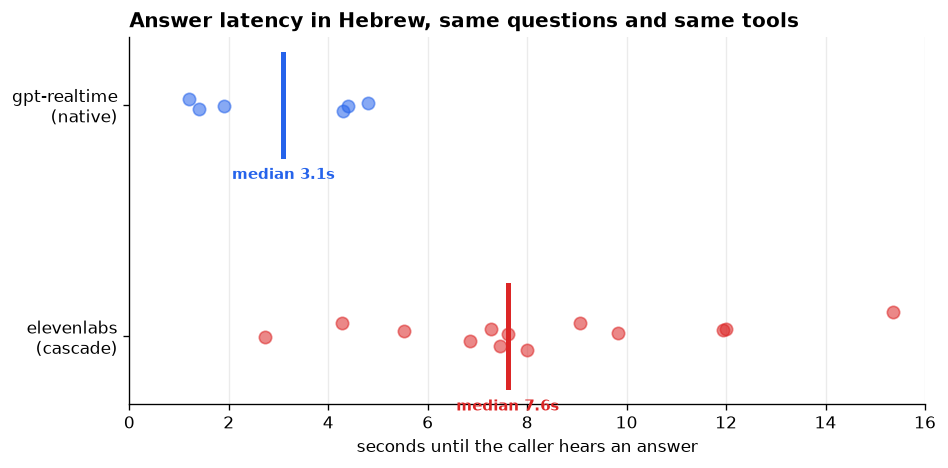

ratio of medians: 2.5x


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
rng = np.random.default_rng(0)

for i, (label, xs, colour) in enumerate([
    ('gpt-realtime', OPENAI_MS, OPENAI),
    ('elevenlabs', ELEVEN_MS, ELEVEN),
]):
    ax.scatter(np.array(xs) / 1000, rng.normal(i, 0.045, len(xs)),
               s=55, color=colour, alpha=0.55, zorder=3)
    m = np.median(xs) / 1000
    ax.plot([m, m], [i - 0.22, i + 0.22], color=colour, lw=3, zorder=4)
    ax.text(m, i + 0.32, f'median {m:.1f}s', color=colour,
            ha='center', fontsize=9, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(['gpt-realtime\n(native)', 'elevenlabs\n(cascade)'])
ax.set_xlabel('seconds until the caller hears an answer')
ax.set_title('Answer latency in Hebrew, same questions and same tools',
             loc='left', fontweight='bold')
ax.set_xlim(0, 16)
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'ratio of medians: {np.median(ELEVEN_MS) / np.median(OPENAI_MS):.1f}x')

**הסתייגות שחייבת להיאמר:** מדגם קטן — 6 תורות מול 13, משיחות שלא נועדו
להיות מדידה מבוקרת. הכיוון חד וחוזר על עצמו; המספר המדויק לא מדויק.

וההטיה דווקא **לטובת** ElevenLabs: המדידה שלו מתחילה אחרי שהתמלול כבר מוכן,
בעוד שזו של OpenAI כוללת את הזיהוי. הפער האמיתי גדול יותר ממה שמוצג.

## 2. איפה הזמן נשרף — ניסוי הבקרה

אם הפער היה במודל, אותו מודל היה איטי גם אצלנו.
אז הרצנו את אותה שאלה בעברית דרך `/api/chat`: **אותו `gemini-3.1-flash-lite`,**
**אותם חמישה כלים, שתי נסיעות למודל — בלי פלטפורמת קול.**

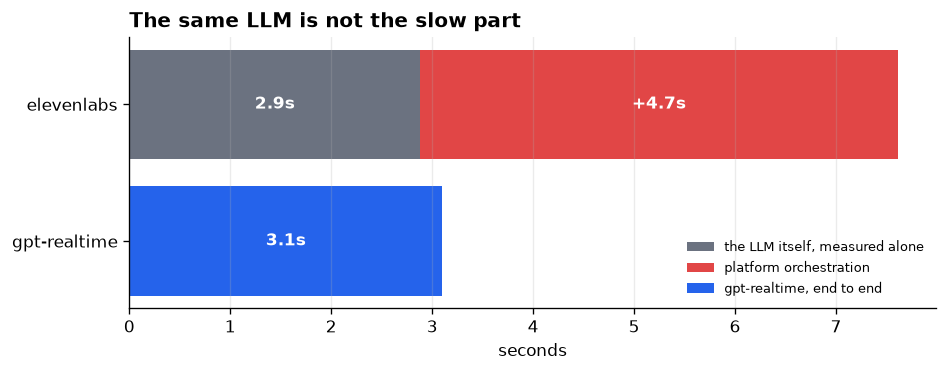

gemini-3.1-flash-lite, on its own : 2.9s
the same model inside the cascade : 7.6s
not explained by the model        : 4.7s


In [4]:
llm_only = np.median(CHAT_MS) / 1000
eleven_total = np.median(ELEVEN_MS) / 1000
openai_total = np.median(OPENAI_MS) / 1000
platform = eleven_total - llm_only

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(1, llm_only, color=NEUTRAL, label='the LLM itself, measured alone')
ax.barh(1, platform, left=llm_only, color=ELEVEN, alpha=0.85, label='platform orchestration')
ax.barh(0, openai_total, color=OPENAI, label='gpt-realtime, end to end')

ax.text(llm_only / 2, 1, f'{llm_only:.1f}s', ha='center', va='center', color='white', fontweight='bold')
ax.text(llm_only + platform / 2, 1, f'+{platform:.1f}s', ha='center', va='center', color='white', fontweight='bold')
ax.text(openai_total / 2, 0, f'{openai_total:.1f}s', ha='center', va='center', color='white', fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(['gpt-realtime', 'elevenlabs'])
ax.set_xlabel('seconds')
ax.set_title('The same LLM is not the slow part', loc='left', fontweight='bold')
ax.legend(loc='lower right', frameon=False, fontsize=8)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

print(f'gemini-3.1-flash-lite, on its own : {llm_only:.1f}s')
print(f'the same model inside the cascade : {eleven_total:.1f}s')
print(f'not explained by the model        : {platform:.1f}s')

**המסקנה:** ה־LLM עושה את העבודה ב־2–3 שניות בשני המקרים.
כל השאר הוא תזמור הפלטפורמה — כולל סבב הכלים שעובר
`ענן ElevenLabs → הדפדפן → localhost → חזרה`: שתי קפיצות אינטרנט נוספות
שאין להן מקבילה במסלול הנייטיב.

## 3. למה הקול לא יכול להציל את זה

השאלה המתבקשת: אולי קול אחר יהיה מהיר יותר?

הסינתזה קורית **אחרי** כל מה שראינו. גם אם ה־TTS היה מיידי,
ההמתנה של 7–10 שניות כבר קרתה. קול הוא סט פרמטרים, לא ארכיטקטורה —
להחליף אותו זה כמו להחליף גופן בציפייה שהדף ירונדר מהר יותר.

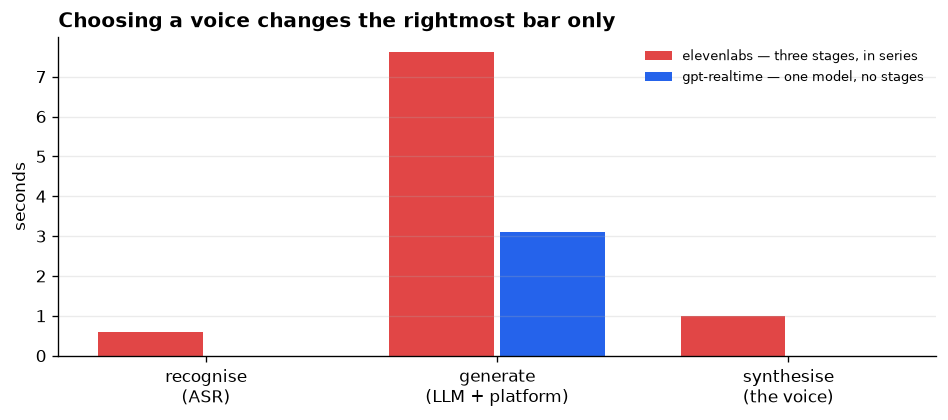

In [5]:
stages = ['recognise\n(ASR)', 'generate\n(LLM + platform)', 'synthesise\n(the voice)']
eleven_stage = [0.6, llm_only + platform, 1.0]
openai_stage = [0.0, openai_total, 0.0]

x = np.arange(len(stages))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - 0.19, eleven_stage, 0.36, color=ELEVEN, alpha=0.85,
       label='elevenlabs — three stages, in series')
ax.bar(x + 0.19, openai_stage, 0.36, color=OPENAI,
       label='gpt-realtime — one model, no stages')

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('seconds')
ax.set_title('Choosing a voice changes the rightmost bar only',
             loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 4. המנוף היחיד שנשאר בשליטתנו: גודל ה־payload

המודל חייב לקרוא את תוצאת הכלי במלואה לפני שהוא מנסח מילה.
נמדד ישירות מ־`POST /api/tool`.

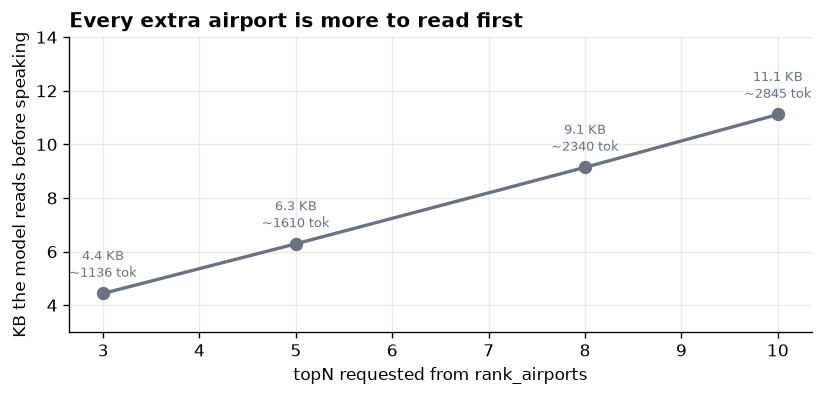

Already applied: the four standing caveats were repeated on every entry.
  before                 13,494 B
  caveats hoisted         9,264 B   -31%
  and topN 3 for speech   4,344 B   -68% against where it started


In [6]:
payload = {3: 4545, 5: 6441, 8: 9363, 10: 11383}  # bytes from rank_airports

fig, ax = plt.subplots(figsize=(7, 3.4))
ns = list(payload)
kb = [payload[n] / 1024 for n in ns]
ax.plot(ns, kb, 'o-', color=NEUTRAL, lw=2, ms=7)
for n, k in zip(ns, kb):
    ax.annotate(f'{k:.1f} KB\n~{int(payload[n] / 4)} tok', (n, k),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color=NEUTRAL)

ax.set_xlabel('topN requested from rank_airports')
ax.set_ylabel('KB the model reads before speaking')
ax.set_title('Every extra airport is more to read first', loc='left', fontweight='bold')
ax.set_ylim(3, 14)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Already applied: the four standing caveats were repeated on every entry.')
print('  before                 13,494 B')
print('  caveats hoisted         9,264 B   -31%')
print('  and topN 3 for speech   4,344 B   -68% against where it started')

## 5. שרשרת הסיבתיות

```
gpt-realtime                      elevenlabs
────────────                      ──────────
מודל אחד                          שלושה שלבים בטור
  audio ──▶ audio                   ASR ──▶ LLM ──▶ TTS

שומע את האודיו עצמו               רואה רק את הטקסט של ה-ASR
  תמלול שגוי = כתובית שגויה         תמלול שגוי = תשובה שגויה

מתחיל לדבר באמצע המשפט            מוסר רק תשובה שלמה
  ההמתנה = עד הטוקן הראשון          ההמתנה = עד היצירה כולה

כלי בתוך ה-session                כלי דרך ענן→דפדפן→localhost→חזרה
  40-80 ms                          40-80 ms + שתי קפיצות אינטרנט

עברית: אותו מודל, ללא עלות        עברית: כפויה על v3_conversational,
                                    האיטי מתשעת מודלי הקול
```

**אף אחת מהשורות האלה אינה הגדרה שאפשר לכוונן.** כולן נובעות מהבחירה
בין מודל נייטיב לקסקדה מנוהלת.

## 6. מה ניסינו, ומה זה קנה

| שינוי | תוצאה |
|---|---|
| דה־דופליקציה של caveats | payload −31% |
| `topN: 3` בקול | payload −68% מהמקור |
| `gemini-2.5-flash` → `3.1-flash-lite` | אותה שכבה כמו מסלול הטקסט |
| `expressive_mode: false` | פחות זמן עד אודיו ראשון |
| `optimize_streaming_latency: 4` | המקסימום שלהם |
| `max_tokens: 400` | חוסם תשובות של שתי פסקאות |
| `turn_eagerness: eager` | **נכשל** — קטיעות עלו 34 שניות מתוך 87 |
| `eleven_realtime_v1_mini` | **חסום** — 403, לא בתוכנית |

אחרי כל אלה הפער נשאר פי 2–3. **זה בדיוק מה שאומר שהוא מבני.**

## 7. ומה שעבד זהה בשני המסלולים

הפער הוא במהירות בלבד. הליבה הדטרמיניסטית התנהגה אותו דבר:

- **מנוע הניקוד: 38–85 מילישניות.** אף פעם לא הצוואר.
- **אותם מספרים בדיוק** — `BOS` מקום 5 מ־158, `PHX` מקום 93, פער ביקוש `+1.4%` מול `−2.3%`.
- **סירב שלוש פעמים** לתת הערכת עלות בנייה, בעברית, תחת לחץ חוזר — בלי להמציא מספר.

`npm run eval` מאמת את זה אוטומטית: 19 מקרים, שני מסלולים,
ובדיקת provenance שמוודאת שכל מספר בפרוזה יצא מתוצאת כלי.